In [ ]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# non centered parameterizaiton

np.random.seed(42)

segments = {
    "Segment_A": {"true_mu": 35, "true_sigma": 4, "n": 50},  # Lots of data
    "Segment_B": {"true_mu": 28, "true_sigma": 3, "n": 30},  # Moderate data
    "Segment_C": {"true_mu": 40, "true_sigma": 5, "n": 2},   # ALMOST NO DATA
}


data_all = []
group_idx = []
group_names = []
for i, (name, params) in enumerate(segments.items()):
    samples = np.random.normal(params["true_mu"], params["true_sigma"], params["n"])
    data_all.extend(samples)
    group_idx.extend([i] * params["n"])
    group_names.append(name)
    print(f"{name}: n={params['n']}, true_mu={params['true_mu']}, sample_mean={samples.mean():.1f}")

data_all = np.array(data_all)
group_idx = np.array(group_idx)
n_groups = len(segments)

In [ ]:
with pm.Model() as ncp_model:
    # hypepriors
    mu_global = pm.Normal("mu_global", mu=30, sigma=10)
    sigma_global = pm.HalfNormal("sigma_global", sigma=10)

    # Instead of mu_segment ~ Normal(mu_global, sigma_global)
    # We sample OFFSETS from a standard Normal...

    # if we do usual (Centered), mu_seg's search space is violently squeezed by sigma_global (during sigmas lower values); as step size cant deal with the wilding changing mag in the funnel
    # For sparse data (where the model relies on the prior), the sampler gets crushed in a 'funnel'.

    # now our sampler only explores this 'offset' which is cylindrical
    # and our mu calced as base+fluctuating type

    offset = pm.Normal("offset", mu=0, sigma=1, shape=n_groups)
    # ...and RECONSTRUCT the actual values
    mu_segment = pm.Deterministic("mu_segment", mu_global + offset * sigma_global)
    sigma_segment = pm.HalfNormal("sigma_segment", sigma = sigma_global, shape=n_groups)
    y = pm.Normal("y", mu = mu_segment[group_idx], sigma = sigma_segment[group_idx], observed=data_all)

    prior_checks = pm.sample_prior_predictive(draws=1000, random_seed=42 )
    trace_ncp = pm.sample(draws=2000, tune=1000, cores=1, random_seed=42, progressbar=False)


fig, ax = plt.subplots(figsize=(8, 4))
az.plot_dist(prior_checks.prior_predictive["y"],
             color="grey",
             label="Prior Predictive (y)",
             ax=ax)
ax.set_title("Prior Predictive Checks")
ax.set_xlabel("Predicted UCS (MPa)")
plt.show()

# arviz deals with data, no blueprints
display(az.summary(trace_ncp, var_names=["mu_global", "mu_segment"]))


az.plot_trace(trace_ncp, var_names=["mu_global", "mu_segment"],
              compact=False, #
              kind="trace")
plt.suptitle("Convergence Check: Trace Plots")
plt.tight_layout()
plt.show()

In [ ]:
# as before but for comparision

with pm.Model() as hierarchial_model:
    # hyper_prior
    mu_global = pm.Normal("mu_global", mu = 30, sigma=10)
    sigma_global = pm.HalfNormal("sigma_global", sigma =10)

    # group prior
    mu_segment = pm.Normal("mu_segment", mu = mu_global, sigma=sigma_global, shape=n_groups)
    sigma_segment = pm.HalfNormal("sigma_segment", sigma = sigma_global, shape=n_groups)


    # likelihood
    y = pm.Normal("y", mu = mu_segment[group_idx], sigma = sigma_segment[group_idx], observed=data_all)

    prior_checks = pm.sample_prior_predictive(draws=1000, random_seed=42 )
    trace_hier = pm.sample(draws=2000, tune=1000, cores=1, random_seed=42, progressbar=False)

    with ncp_model:
        trace_new = pm.sample(
        draws=2000,
        tune=1000,
        cores=1,
        random_seed=42,
        progressbar=False,
        target_accept=0.95  # Force smaller step sizes (can go up to 0.99) # takes longer tho
)

In [ ]:
# count divergences

div_new = trace_new.sample_stats["diverging"].values.sum()
div_centered = trace_hier.sample_stats["diverging"].values.sum()
div_nc = trace_ncp.sample_stats["diverging"].values.sum()



# estimates are THE SAME (just sampled better)
for i, name in enumerate(group_names):
    centered_est = trace_hier.posterior["mu_segment"].values.reshape(-1, n_groups)[:, i].mean()
    nc_est = trace_ncp.posterior["mu_segment"].values.reshape(-1, n_groups)[:, i].mean()
    #print(f"{name}: Centered={centered_est:.1f}, Non-centered={nc_est:.1f}")

# display(az.summary(trace_ncp, var_names=["mu_global", "mu_segment"]))
# confused cuz thought rhat was 1, so why divergence/

# rhat is for the whole model divergence, that is our local integration error (fix by target_accept = 0.95)


print(f"\nCentered parameterization:         {div_centered} divergences")
print(f"Non-centered parameterization:     {div_nc} divergences")
print(f"Non-centered (target_accept=0.95): {div_new} divergences")
print(f"{'FIXED!' if div_nc < div_centered else 'Both clean (your data was easy)'}\n")

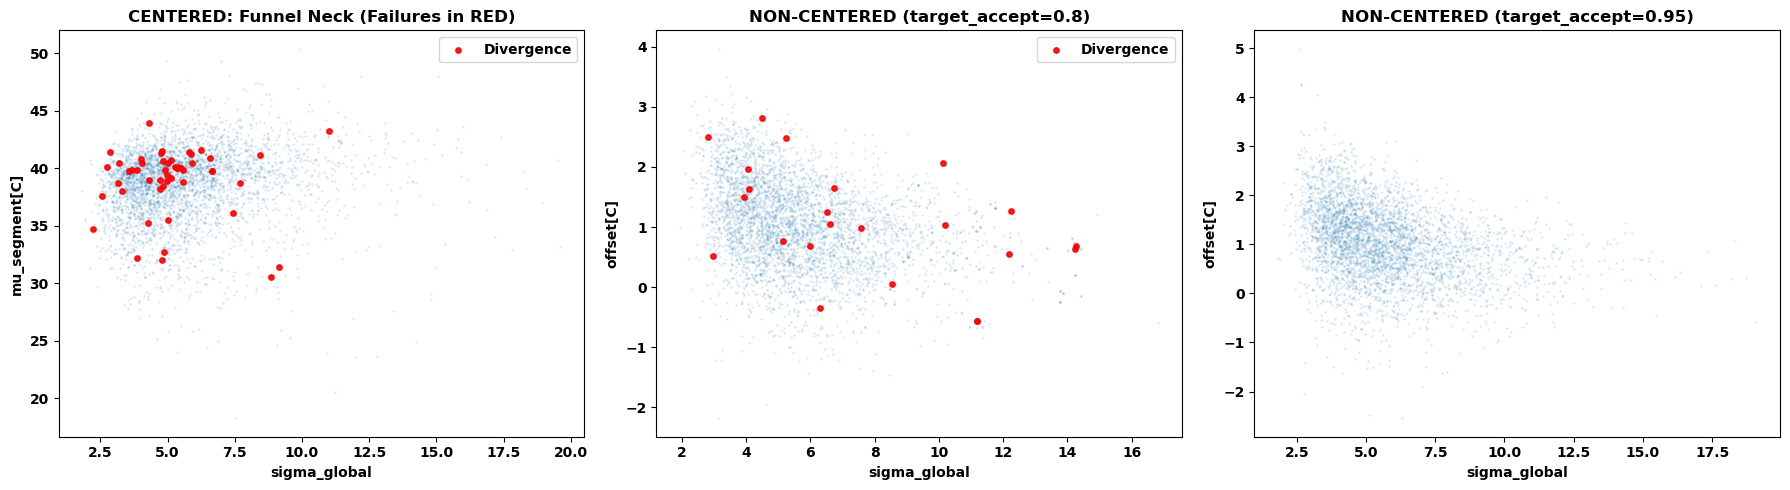

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Extract divergence masks to perform forensics
div_c = trace_hier.sample_stats["diverging"].values.flatten()
div_nc = trace_ncp.sample_stats["diverging"].values.flatten()
div_new = trace_new.sample_stats["diverging"].values.flatten()

# 1. Centered: mu_segment vs sigma_global
c_mu = trace_hier.posterior["mu_segment"].values.reshape(-1, n_groups)[:, 2]
c_sig = trace_hier.posterior["sigma_global"].values.flatten()

axes[0].scatter(c_sig[~div_c], c_mu[~div_c], alpha=0.1, s=1, color='tab:blue')
if div_c.sum() > 0:
    axes[0].scatter(c_sig[div_c], c_mu[div_c], alpha=0.9, s=15, color='red', label="Divergence")
axes[0].set_xlabel("sigma_global")
axes[0].set_ylabel("mu_segment[C]")
axes[0].set_title("CENTERED: Funnel Neck (Failures in RED)")
if div_c.sum() > 0: axes[0].legend()


# 2. Non-centered (target_accept=0.8): offset vs sigma_global
nc_off = trace_ncp.posterior["offset"].values.reshape(-1, n_groups)[:, 2]
nc_sig = trace_ncp.posterior["sigma_global"].values.flatten()

axes[1].scatter(nc_sig[~div_nc], nc_off[~div_nc], alpha=0.1, s=1, color='tab:blue')
if div_nc.sum() > 0:
    axes[1].scatter(nc_sig[div_nc], nc_off[div_nc], alpha=0.9, s=15, color='red', label="Divergence")
axes[1].set_xlabel("sigma_global")
axes[1].set_ylabel("offset[C]")
axes[1].set_title("NON-CENTERED (target_accept=0.8)")
if div_nc.sum() > 0: axes[1].legend()


# 3. Non-centered (target_accept=0.95): offset vs sigma_global
new_off = trace_new.posterior["offset"].values.reshape(-1, n_groups)[:, 2]
new_sig = trace_new.posterior["sigma_global"].values.flatten()

axes[2].scatter(new_sig[~div_new], new_off[~div_new], alpha=0.1, s=1, color='tab:blue')
if div_new.sum() > 0:
    axes[2].scatter(new_sig[div_new], new_off[div_new], alpha=0.9, s=15, color='red', label="Divergence")
axes[2].set_xlabel("sigma_global")
axes[2].set_ylabel("offset[C]")
axes[2].set_title("NON-CENTERED (target_accept=0.95)")
if div_new.sum() > 0: axes[2].legend()

plt.tight_layout()
plt.show()

# we can observe that on leftmost failures are concentrated aroud sigma <7, model ignores this region and
# becomes blind to scenarios for such cases underestimating the true range of risk